# Analyse query-understanding predictions

Score Qwen3.5 0.8b / 2b / 4b query plans against ground truth:

Metrics:
- in-scope accuracy (overall / GT-true / GT-false),
- keyword recall and precision,
- HyDE retrieval (`hyde_beats_raw`, `hyde_recall@5`, `hyde_recall@20`) when `imet_eval` embeddings are available.

Write `eval/results/query_understanding_results.csv`, then visualise.

## 0. Setup


In [3]:
# %pip install -q pandas matplotlib rapidfuzz

In [4]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from rapidfuzz import fuzz
from sqlalchemy import create_engine, select

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Navigate up until eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "recall" / "recall_queries.jsonl"
PRED_DIR = REPO_ROOT / "eval" / "predictions" / "query_understanding"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "query_understanding_results.csv"

# Models to load from eval/predictions/query_understanding/{model}.jsonl
MODELS = ["qwen3.5_4b", "qwen3.5_2b", "qwen3.5_0.8b"]

EMPTY_PREDICTION = {"in_scope": False, "keywords": [], "hyde_rewrite": ""}
FUZZ_THRESHOLD = 85
HYDE_RECALL_KS = (5, 20)

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED_DIR:", PRED_DIR)

REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/recall/recall_queries.jsonl
PRED_DIR: /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions/query_understanding


## 1. Load

Read the prediction JSONLs, join ground truth on `id`, dump into one DataFrame.


In [5]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        rows.append(json.loads(line))
    return rows


def prediction_or_empty(row: dict) -> dict:
    """
    Return the prediction dict, or the empty plan on missing/invalid prediction.
    """
    pred = row.get("prediction")
    if not isinstance(pred, dict):
        return dict(EMPTY_PREDICTION)

    return {
        "in_scope": bool(pred.get("in_scope", False)),
        "keywords": pred.get("keywords") if isinstance(pred.get("keywords"), list) else [],
        "hyde_rewrite": pred.get("hyde_rewrite") if isinstance(pred.get("hyde_rewrite"), str) else "",
    }


# Step 1: Load ground truth and index by id
gt_rows = load_jsonl(GT_PATH)
gt_by_id = {int(row["id"]): row for row in gt_rows}

# Step 2: Load each model's predictions and join GT on id
pred_rows: list[dict] = []
pred_raw_by_model: dict[str, list[dict]] = {}
for model in MODELS:
    pred_path = PRED_DIR / f"{model}.jsonl"
    if not pred_path.is_file():
        print(f"missing: {pred_path}")
        continue

    raw = load_jsonl(pred_path)
    pred_raw_by_model[model] = raw
    for row in raw:
        row_id = int(row["id"])
        gt = gt_by_id.get(row_id) or {}
        expected = gt.get("expected") or {}
        pred = prediction_or_empty(row)
        pred_rows.append({
            "model": row.get("model") or model,
            "id": row_id,
            "query": gt.get("query") or "",
            "gt_in_scope": bool(expected.get("in_scope", False)),
            "gt_keywords": expected.get("keywords") or [],
            "gt_hyde": expected.get("hyde_rewrite") or "",
            "gt_contact_ids": expected.get("contact_ids") or [],
            "pred_in_scope": pred["in_scope"],
            "pred_keywords": pred["keywords"],
            "pred_hyde": pred["hyde_rewrite"],
            "latency_ms": row.get("latency_ms"),
            "error": row.get("error"),
        })

pred_df = pd.DataFrame(pred_rows)
print(pred_df.shape)
pred_df.head()


(180, 12)


,model,id,query,gt_in_scope,gt_keywords,gt_hyde,gt_contact_ids,pred_in_scope,pred_keywords,pred_hyde,latency_ms,error
0,qwen3.5_4b,1,who likes hiking,True,"[hiking, outdoors]",Enjoys hiking and outdoor walks in hills or na...,"[1, 48, 50, 87, 107, 132, 140, 143]",True,"[hiking, outdoors]",Enjoys hiking and outdoor activities.,8931.57,NaN
1,qwen3.5_4b,2,who boulders or climbs,True,"[climbing, bouldering]",Climbs or boulders regularly at an indoor wall...,"[4, 5, 25, 27, 44, 55, 62, 68, 77, 82, 98, 113...",True,"[boulders, climbs]",A person who enjoys bouldering and climbing ac...,3232.73,NaN
2,qwen3.5_4b,3,who works in fintech,True,"[fintech, payments]",Works at a financial technology or payments co...,"[3, 4, 44, 58, 67, 98, 105, 115]",True,"[fintech, finance technology]",Works in finance technology and financial serv...,3010.11,NaN
3,qwen3.5_4b,4,who is a product designer,True,"[product design, interaction design, designer]",Product or interaction designer. Talks about U...,"[20, 42, 79, 101, 113, 116, 138, 139]",True,[product designer],A professional who designs user interfaces and...,2810.08,NaN
4,qwen3.5_4b,5,who did I meet at the career fair,True,"[career fair, ExCeL]",Met at a campus or industry career fair. Discu...,"[1, 2, 55, 56, 67, 76]",True,"[career fair, met, contact]",Attended a career event and connected with sev...,3248.98,NaN


## 2. Score each row

For each query:

- **in_scope** exact bool match
- **keywords** greedy 1-to-1 matching (exact / substring / RapidFuzz ≥ 85)
- **HyDE empty** when the predicted rewrite is blank
- **HyDE vs GT rewrite** RapidFuzz ratio (diagnostic only; not written to CSV)


In [6]:
def normalise_token(token: str) -> str:
    """
    Lowercase and strip a keyword token for matching.
    """
    return token.strip().lower()


def tokens_match(expected: str, predicted: str) -> bool:
    """
    Check if the predicted keyword token matches the expected keyword token.
    """
    # Exact match after normalisation
    if expected == predicted:
        return True
    # Substring either way
    if expected in predicted or predicted in expected:
        return True
    # RapidFuzz fallback
    return fuzz.ratio(expected, predicted) >= FUZZ_THRESHOLD



def greedy_keyword_matches(expected: list[str], predicted: list[str]) -> int:
    """
    Counts how many ground-truth keywords got a unique predicted partner.
    """
    # Normalise tokens and drop empties
    expected_norm = [normalise_token(t) for t in expected if t.strip()]
    predicted_norm = [normalise_token(t) for t in predicted if t.strip()]
    used: set[int] = set()
    matched = 0

    # Greedy: for each expected token, take the first unused predicted match
    for exp in expected_norm:
        # Scan predicted tokens left to right, skip ones already paired
        for i, pred in enumerate(predicted_norm):
            if i in used:
                continue
            if tokens_match(exp, pred):
                # Lock this predicted token so it cannot match another GT token
                used.add(i)
                matched += 1
                break
    
    return matched


scored_rows: list[dict] = []
for row in pred_df.itertuples(index=False):
    # Keep non-empty string keywords only
    expected = [kw for kw in (row.gt_keywords or []) if isinstance(kw, str) and kw.strip()]
    predicted = [kw for kw in (row.pred_keywords or []) if isinstance(kw, str) and kw.strip()]
    # Count how many ground-truth keywords got a unique predicted partner
    matched = greedy_keyword_matches(expected, predicted)

    # NaN when there is no denominator (no GT keywords / no predicted keywords)
    kw_recall = (matched / len(expected)) if expected else float("nan")
    kw_precision = (matched / len(predicted)) if predicted else float("nan")

    pred_hyde = (row.pred_hyde or "").strip()
    gt_hyde = (row.gt_hyde or "").strip()
    # Diagnostic only: RapidFuzz ratio of predicted HyDE vs GT rewrite
    hyde_vs_gt = fuzz.ratio(pred_hyde, gt_hyde) / 100.0 if pred_hyde and gt_hyde else float("nan")

    # Empty plan: no keywords and no HyDE rewrite
    empty_plan = (not predicted) and (not pred_hyde)

    scored_rows.append({
        "model": row.model,
        "id": row.id,
        "query": row.query,
        "gt_in_scope": row.gt_in_scope,
        "in_scope_correct": int(bool(row.pred_in_scope) is bool(row.gt_in_scope)),
        "kw_matched": matched,
        "kw_expected_n": len(expected),
        "kw_predicted_n": len(predicted),
        "kw_recall": kw_recall,
        "kw_precision": kw_precision,
        "hyde_empty": int(not pred_hyde),
        "hyde_vs_gt": hyde_vs_gt,
        "empty_plan": int(empty_plan),
        "error_flag": int(row.error is not None and str(row.error).strip() != ""),
        "latency_ms": row.latency_ms,
    })

# Dump per-query scores into one DataFrame
scored_df = pd.DataFrame(scored_rows)
display(scored_df.head(5))

# Per-model diagnostic rates
diagnostics = (
    scored_df.groupby("model", as_index=False)
    .agg(
        n=("id", "size"),
        empty_plan_rate=("empty_plan", "mean"),
        error_rate=("error_flag", "mean"),
        hyde_empty_rate=("hyde_empty", "mean"),
    )
)
diagnostics


,model,id,query,gt_in_scope,in_scope_correct,kw_matched,kw_expected_n,kw_predicted_n,kw_recall,kw_precision,hyde_empty,hyde_vs_gt,empty_plan,error_flag,latency_ms
0,qwen3.5_4b,1,who likes hiking,True,1,2,2,2,1.000000,1.000000,0,0.465753,0,1,8931.57
1,qwen3.5_4b,2,who boulders or climbs,True,1,0,2,2,0.000000,0.000000,0,0.441718,0,1,3232.73
2,qwen3.5_4b,3,who works in fintech,True,1,1,2,2,0.500000,0.500000,0,0.503226,0,1,3010.11
3,qwen3.5_4b,4,who is a product designer,True,1,1,3,1,0.333333,1.000000,0,0.425806,0,1,2810.08
4,qwen3.5_4b,5,who did I meet at the career fair,True,1,1,2,3,0.500000,0.333333,0,0.432990,0,1,3248.98


,model,n,empty_plan_rate,error_rate,hyde_empty_rate
0,qwen3.5_0.8b,60,0.983333,1.0,0.983333
1,qwen3.5_2b,60,0.050000,1.0,0.050000
2,qwen3.5_4b,60,0.233333,1.0,0.233333


## 3. Aggregate

Long-format metrics per `model`:

| metric | how |
|---|---|
| `in_scope_acc` | mean exact bool match |
| `in_scope_acc_true` | accuracy on GT in-scope queries |
| `in_scope_acc_false` | accuracy on GT out-of-scope queries |
| `keyword_recall` | pooled matched tokens / GT tokens |
| `keyword_precision` | pooled matched tokens / predicted tokens |
| `hyde_beats_raw` | share of expected contacts where HyDE cosine beats the raw query |
| `hyde_recall@5` / `hyde_recall@20` | expected contacts in the HyDE top-K |
| `latency_ms_mean` | copied onto every metric row |


In [7]:
def mean(values: list[float]) -> float | None:
    """
    Return the arithmetic mean, or None if the list is empty.
    """
    if not values:
        return None
    return float(sum(values) / len(values))


def dot(a: list[float], b: list[float]) -> float:
    """
    Dot product of two embeddings.
    Embeddings are L2-normalised so this is cosine similarity.
    """
    return float(sum(x * y for x, y in zip(a, b, strict=True)))


def load_contact_embeddings() -> dict[int, list[float]]:
    """
    Pulls every contact embedding out of the eval database
    so HyDE scoring can rank contacts without calling Postgres on every query.

    Steps:
    1. Load EVAL_DATABASE_URL
    2. Query embedded contacts
    """
    # Step 1: Load env then import backend models
    load_dotenv(REPO_ROOT / ".env.local")
    # Puts repo root on Python import path to import backend models
    sys.path.insert(0, str(REPO_ROOT))
    from backend.models import Contact

    raw = os.environ.get("EVAL_DATABASE_URL", "").strip()
    if not raw:
        raise SystemExit("EVAL_DATABASE_URL is missing. Set it in .env.local")

    # Step 2: Query embedded contacts
    engine = create_engine(raw, pool_pre_ping=True)
    embeddings: dict[int, list[float]] = {}
    with engine.connect() as conn:
        rows = conn.execute(
            select(Contact.id, Contact.profile_embedding).where(
                Contact.profile_embedding.isnot(None)
            )
        ).all()
        # Build a mapping of contact id to embedding
        for contact_id, vector in rows:
            if vector is None:
                continue
            embeddings[int(contact_id)] = list(vector)
    engine.dispose()

    # Handle no contact embeddings
    if not embeddings:
        raise SystemExit(
            "imet_eval has no contact embeddings. "
            "Run: python eval/scripts/recall/seed_eval_db.py"
        )
    return embeddings


def score_hyde(
    gt_rows: list[dict],
    pred_by_id: dict[int, dict],
    contact_embeddings: dict[int, list[float]],
) -> list[dict]:
    """
    Score the quality of the HyDE retrieval vs the raw query.
    """
    from backend.ai.embeddings.bge import get_embedder

    # Get the same embedder as main app
    embedder = get_embedder()
    # List of all contact ids
    ranked_ids = list(contact_embeddings.keys())
    # Lists for HyDE scoring metrics
    beats: list[float] = []
    # One recall list per cutoff, keyed by K
    recalls: dict[int, list[float]] = {k: [] for k in HYDE_RECALL_KS}

    for gt in gt_rows:
        expected_ids = [int(i) for i in (gt["expected"].get("contact_ids") or [])]
        # Skip out-of-scope / no-match queries
        if not expected_ids:
            continue
        # Drop expected ids that were not seeded into imet_eval
        expected_ids = [i for i in expected_ids if i in contact_embeddings]
        if not expected_ids:
            continue

        pred = prediction_or_empty(pred_by_id[gt["id"]])
        raw_query = gt["query"].strip()
        hyde_text = (pred["hyde_rewrite"] or "").strip()
        # Skip if the LLM produced no HyDE rewrite
        if not hyde_text:
            continue

        # Embed raw query and HyDE rewrite
        raw_vec = embedder.embed_text(raw_query)
        hyde_vec = embedder.embed_text(hyde_text)

        # Build a list of beat flags for each expected contact
        beat_flags = [
            1.0
            if dot(hyde_vec, contact_embeddings[cid]) > dot(raw_vec, contact_embeddings[cid])
            else 0.0
            for cid in expected_ids
        ]
        beats.append(sum(beat_flags) / len(beat_flags))

        # Rank contacts by HyDE cosine (descending)
        scored = sorted(
            ranked_ids,
            key=lambda cid: dot(hyde_vec, contact_embeddings[cid]),
            reverse=True,
        )
        expected_id_set = set(expected_ids)

        # recall@K: expected contacts found in the top K, divided by how many could fit there.
        # Cap the denominator at K so queries with more than K expected contacts can still score 1.0
        for k in HYDE_RECALL_KS:
            top_k = scored[:k]
            recalls[k].append(
                sum(1 for cid in top_k if cid in expected_id_set)
                / min(len(expected_ids), k)
            )

    # Calculate the mean for each metric
    return [
        {"metric": "hyde_beats_raw", "value": mean(beats), "n": len(beats)},
        *[
            {
                "metric": f"hyde_recall@{k}",
                "value": mean(recalls[k]),
                "n": len(recalls[k]),
            }
            for k in HYDE_RECALL_KS
        ],
    ]

# Load imet_eval embeddings for HyDE scoring (skip if DB is down)
contact_embeddings = None
try:
    contact_embeddings = load_contact_embeddings()
    print(f"Loaded {len(contact_embeddings)} contact embeddings from imet_eval")
except Exception as exc:
    print(f"Skipping HyDE retrieval metrics: {exc}")

# Aggregate per-query scores into long-format metric rows
csv_rows: list[dict] = []
for model, group in scored_df.groupby("model", sort=False):
    # Skip rows with no latency
    latencies = [
        float(v) for v in group["latency_ms"].dropna().tolist()
    ]
    latency_ms_mean = mean(latencies)

    # Split based on ground truth in-scope / out-of-scope
    overall = group["in_scope_correct"].astype(float).tolist()
    when_true = group.loc[group["gt_in_scope"], "in_scope_correct"].astype(float).tolist()
    when_false = group.loc[~group["gt_in_scope"], "in_scope_correct"].astype(float).tolist()

    metric_rows = [
        {"metric": "in_scope_acc", "value": mean(overall), "n": len(overall)},
        {"metric": "in_scope_acc_true", "value": mean(when_true), "n": len(when_true)},
        {"metric": "in_scope_acc_false", "value": mean(when_false), "n": len(when_false)},
    ]

    # Pooled keyword recall / precision (skip queries with no GT or predicted keywords)
    expected_total = int(group["kw_expected_n"].sum())
    predicted_total = int(group["kw_predicted_n"].sum())
    matched_expected = int(
        group.loc[group["kw_expected_n"] > 0, "kw_matched"].sum()
    )
    matched_predicted = int(
        group.loc[group["kw_predicted_n"] > 0, "kw_matched"].sum()
    )
    keyword_recall = (matched_expected / expected_total) if expected_total else None
    keyword_precision = (matched_predicted / predicted_total) if predicted_total else None
    metric_rows.extend(
        [
            {"metric": "keyword_recall", "value": keyword_recall, "n": expected_total},
            {"metric": "keyword_precision", "value": keyword_precision, "n": predicted_total},
        ]
    )

    # HyDE retrieval metrics
    if contact_embeddings is not None and model in pred_raw_by_model:
        pred_by_id = {int(row["id"]): row for row in pred_raw_by_model[model]}
        metric_rows.extend(score_hyde(gt_rows, pred_by_id, contact_embeddings))

    # Copy mean LLM latency onto every metric row
    for row in metric_rows:
        csv_rows.append(
            {
                "model": model,
                "metric": row["metric"],
                "value": row["value"],
                "n": row["n"],
                "latency_ms_mean": latency_ms_mean,
            }
        )

results = pd.DataFrame(csv_rows)
display(results)

Loaded 150 contact embeddings from imet_eval


/Users/desmond/Documents/University/Y3/FP/imet/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7711.33it/s]


,model,metric,value,n,latency_ms_mean
0,qwen3.5_4b,in_scope_acc,0.883333,60,3477.597833
1,qwen3.5_4b,in_scope_acc_true,0.897959,49,3477.597833
2,qwen3.5_4b,in_scope_acc_false,0.818182,11,3477.597833
3,qwen3.5_4b,keyword_recall,0.495652,115,3477.597833
4,qwen3.5_4b,keyword_precision,0.606383,94,3477.597833
5,qwen3.5_4b,hyde_beats_raw,0.539075,36,3477.597833
6,qwen3.5_4b,hyde_recall@5,0.595370,36,3477.597833
7,qwen3.5_4b,hyde_recall@20,0.666380,36,3477.597833
8,qwen3.5_2b,in_scope_acc,0.866667,60,2294.311167
9,qwen3.5_2b,in_scope_acc_true,1.000000,49,2294.311167


In [8]:
# Wide table for a quick model comparison
agg = results.pivot_table(index="model", columns="metric", values="value")
agg = agg.reindex(index=[m for m in MODELS if m in set(results["model"])])
agg

metric,hyde_beats_raw,hyde_recall@20,hyde_recall@5,in_scope_acc,in_scope_acc_false,in_scope_acc_true,keyword_precision,keyword_recall
model,,,,,,,,
qwen3.5_4b,0.539075,0.666380,0.595370,0.883333,0.818182,0.897959,0.606383,0.495652
qwen3.5_2b,0.306578,0.699182,0.627778,0.866667,0.272727,1.000000,0.580357,0.565217
qwen3.5_0.8b,NaN,NaN,NaN,0.200000,1.000000,0.020408,0.500000,0.008696


## 4. Save

Overwrite `eval/results/query_understanding_results.csv`.


In [9]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Convert results df to CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")
results.head(10)

Wrote 24 rows to eval/results/query_understanding_results.csv


,model,metric,value,n,latency_ms_mean
0,qwen3.5_4b,in_scope_acc,0.883333,60,3477.597833
1,qwen3.5_4b,in_scope_acc_true,0.897959,49,3477.597833
2,qwen3.5_4b,in_scope_acc_false,0.818182,11,3477.597833
3,qwen3.5_4b,keyword_recall,0.495652,115,3477.597833
4,qwen3.5_4b,keyword_precision,0.606383,94,3477.597833
5,qwen3.5_4b,hyde_beats_raw,0.539075,36,3477.597833
6,qwen3.5_4b,hyde_recall@5,0.595370,36,3477.597833
7,qwen3.5_4b,hyde_recall@20,0.666380,36,3477.597833
8,qwen3.5_2b,in_scope_acc,0.866667,60,2294.311167
9,qwen3.5_2b,in_scope_acc_true,1.000000,49,2294.311167


## 5. Visualisation

1. In-scope accuracy (overall / GT-true / GT-false)
2. Keyword recall vs precision
3. HyDE retrieval (omit if embeddings were unavailable)
4. In-scope accuracy vs latency scatter


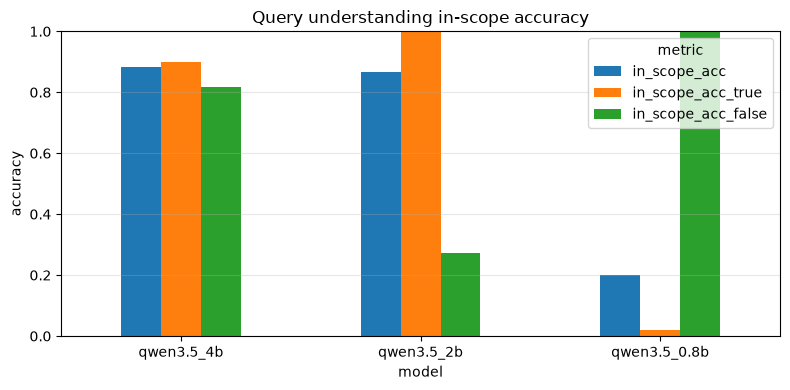

In [10]:
model_order = [m for m in MODELS if m in set(results["model"])]

in_scope_metrics = ["in_scope_acc", "in_scope_acc_true", "in_scope_acc_false"]
in_scope = results[results["metric"].isin(in_scope_metrics)].copy()
pivot_in_scope = in_scope.pivot(index="model", columns="metric", values="value")
pivot_in_scope = pivot_in_scope.reindex(index=model_order, columns=in_scope_metrics)

ax = pivot_in_scope.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("accuracy")
ax.set_xlabel("model")
ax.set_title("Query understanding in-scope accuracy")
ax.set_ylim(0, 1)
ax.legend(title="metric")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

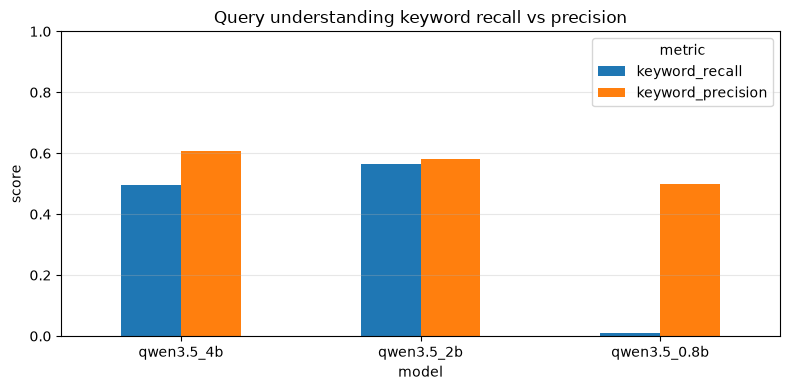

In [11]:
kw_metrics = ["keyword_recall", "keyword_precision"]
kw = results[results["metric"].isin(kw_metrics)].copy()
pivot_kw = kw.pivot(index="model", columns="metric", values="value")
pivot_kw = pivot_kw.reindex(index=model_order, columns=kw_metrics)

ax = pivot_kw.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("score")
ax.set_xlabel("model")
ax.set_title("Query understanding keyword recall vs precision")
ax.set_ylim(0, 1)
ax.legend(title="metric")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

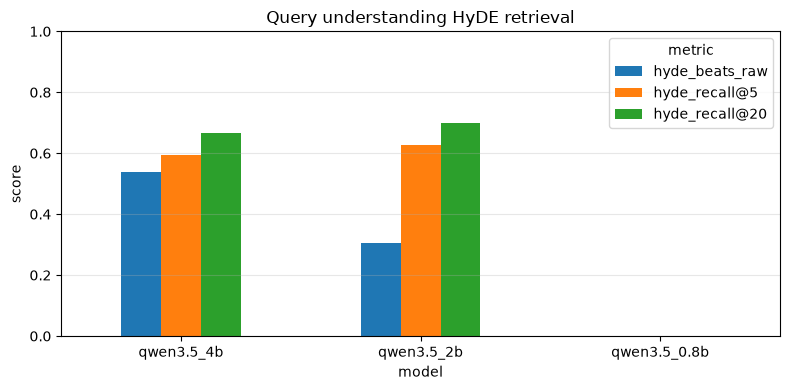

In [12]:
hyde_metrics = ["hyde_beats_raw", "hyde_recall@5", "hyde_recall@20"]
hyde = results[results["metric"].isin(hyde_metrics)].copy()
if hyde.empty:
    print("No HyDE retrieval metrics to plot (embeddings unavailable).")
else:
    pivot_hyde = hyde.pivot(index="model", columns="metric", values="value")
    pivot_hyde = pivot_hyde.reindex(index=model_order, columns=hyde_metrics)

    ax = pivot_hyde.plot(kind="bar", figsize=(8, 4), rot=0)
    ax.set_ylabel("score")
    ax.set_xlabel("model")
    ax.set_title("Query understanding HyDE retrieval")
    ax.set_ylim(0, 1)
    ax.legend(title="metric")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

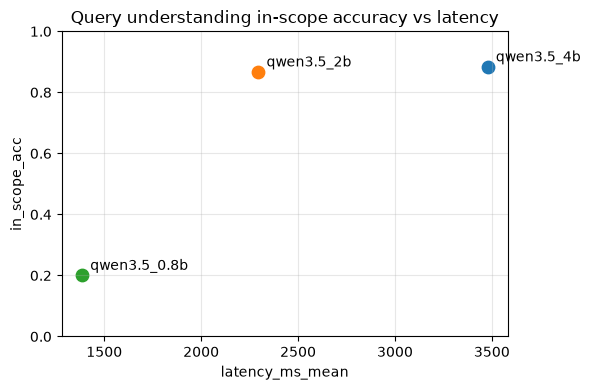

In [13]:
scatter = (
    results[results["metric"] == "in_scope_acc"][
        ["model", "value", "latency_ms_mean"]
    ]
    .drop_duplicates("model")
    .set_index("model")
    .reindex(model_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 4))
for _, row in scatter.iterrows():
    ax.scatter(row["latency_ms_mean"], row["value"], s=80)
    ax.annotate(row["model"], (row["latency_ms_mean"], row["value"]), textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("latency_ms_mean")
ax.set_ylabel("in_scope_acc")
ax.set_title("Query understanding in-scope accuracy vs latency")
ax.set_ylim(0, 1)
ax.grid(axis="both", alpha=0.3)
plt.tight_layout()
plt.show()